<a href="https://colab.research.google.com/github/ucsekhar409/Applieddatascienceandstats/blob/main/COVID_FINAL_Complete_Adavi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## <span style="color:#2e7d5b">&#9632;</span> <span style="color:#2b2d42">**1. Imports**</span>

In [ ]:
import warnings, re; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split, GridSearchCV, learning_curve
from sklearn.inspection import permutation_importance
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from lightgbm import LGBMClassifier
from sklearn.metrics import (roc_auc_score, accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_curve, precision_recall_curve)
SEED=42; TARGET='covid_vaccine'; ID='respondent_id'

import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
EMERALD,CHARCOAL,AMBER,ROSE,STEEL='#2e7d5b','#2b2d42','#e0a458','#b5446e','#3d6098'
PALETTE=[EMERALD,AMBER,STEEL,ROSE,CHARCOAL]
plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'#f7faf8','axes.edgecolor':CHARCOAL,
    'axes.titleweight':'bold','axes.titlesize':13,'axes.titlecolor':CHARCOAL,'axes.labelcolor':CHARCOAL,
    'text.color':CHARCOAL,'xtick.color':CHARCOAL,'ytick.color':CHARCOAL,'axes.prop_cycle':plt.cycler(color=PALETTE),'figure.dpi':110})
CMAP='Greens'

## <span style="color:#2e7d5b">&#9632;</span> <span style="color:#2b2d42">**2. Load Data**</span>

In [ ]:
train=pd.read_csv('dataset_C_training.csv'); test=pd.read_csv('dataset_C_testing.csv')
sample=pd.read_csv('dataset_C_example_submission.csv')
y=train[TARGET].values; print('train',train.shape,'test',test.shape); train.head()

train (4756, 31) test (4749, 30)


,respondent_id,covid_concern,covid_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,employment_status,census_msa,household_adults,household_children,doctor_recc_covid,opinion_covid_vacc_effective,opinion_covid_risk,opinion_covid_sick_from_vacc,employment_sector,covid_vaccine
0,1,3.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,Employed,"MSA, Principle City",3.0,2.0,0,4,4,2.0,construction,0
1,2,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Employed,Non-MSA,0.0,0.0,0,5,2,1.0,education,1
2,3,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Employed,"MSA, Not Principle City",0.0,0.0,0,2,2,5.0,wholesale,0
3,4,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Not in Labor Force,"MSA, Not Principle City",1.0,0.0,1,3,3,2.0,NaN,1
4,5,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Employed,"MSA, Not Principle City",0.0,0.0,0,3,2,2.0,wholesale,0


## <span style="color:#2e7d5b">&#9632;</span> <span style="color:#2b2d42">**3. Exploratory Data Analysis**</span>

### <span style="color:#3d6098">**3.1 Target Distribution — Donut Chart**</span>

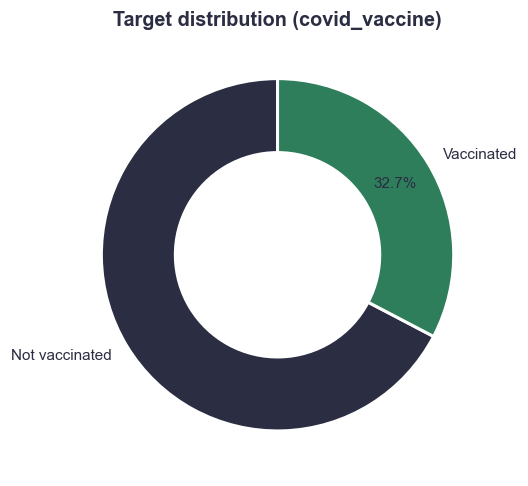

In [ ]:
vc=pd.Series(y).value_counts().sort_index()
plt.figure(figsize=(5.2,5.2))
plt.pie(vc.values, labels=['Not vaccinated','Vaccinated'], colors=[CHARCOAL,EMERALD],
        autopct='%1.1f%%', startangle=90, pctdistance=0.78,
        wedgeprops=dict(width=0.42,edgecolor='white',linewidth=2), textprops={'color':CHARCOAL})
plt.title('Target distribution (covid_vaccine)'); plt.show()

### <span style="color:#3d6098">**3.2 Missing Values — Lollipop Chart**</span>

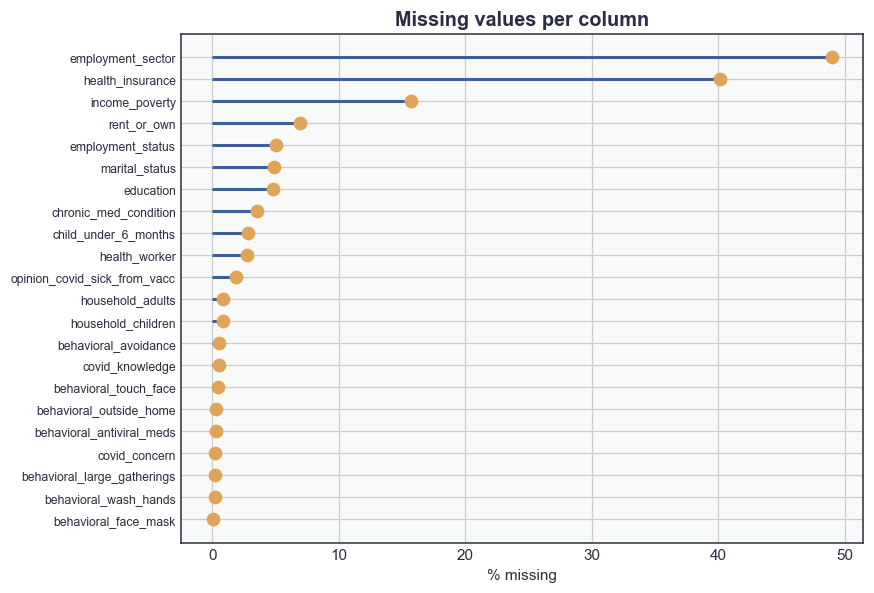

In [ ]:
miss=(train.isna().mean()*100); miss=miss[miss>0].sort_values()
plt.figure(figsize=(8,6))
plt.hlines(range(len(miss)),0,miss.values,color=STEEL,lw=2)
plt.plot(miss.values,range(len(miss)),'o',color=AMBER,ms=8)
plt.yticks(range(len(miss)),miss.index,fontsize=8); plt.xlabel('% missing'); plt.title('Missing values per column'); plt.show()

### <span style="color:#3d6098">**3.3 Feature Distributions by Vaccination Status — Box Plots**</span>

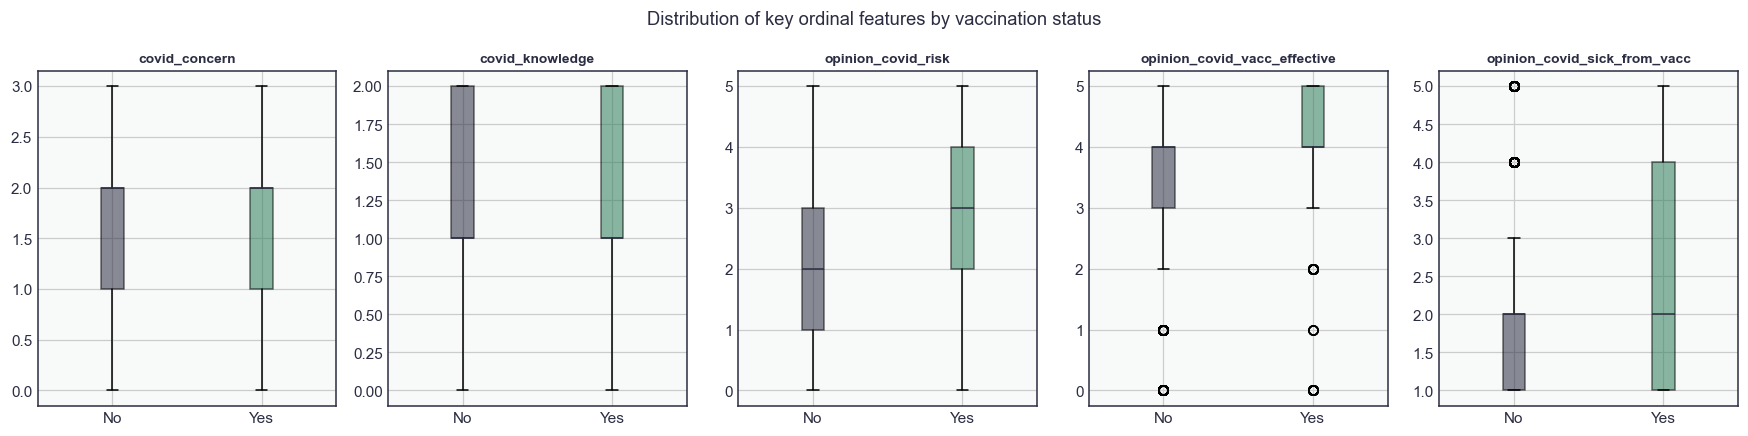

In [ ]:
feats=['covid_concern','covid_knowledge','opinion_covid_risk','opinion_covid_vacc_effective','opinion_covid_sick_from_vacc']
fig,ax=plt.subplots(1,len(feats),figsize=(16,4))
for a,fcol in zip(ax,feats):
    d0=train.loc[y==0,fcol].dropna(); d1=train.loc[y==1,fcol].dropna()
    bp=a.boxplot([d0,d1],labels=['No','Yes'],patch_artist=True,medianprops=dict(color=CHARCOAL))
    for patch,col in zip(bp['boxes'],[CHARCOAL,EMERALD]): patch.set_facecolor(col); patch.set_alpha(.55)
    a.set_title(fcol,fontsize=9)
plt.suptitle('Distribution of key ordinal features by vaccination status'); plt.tight_layout(); plt.show()

### <span style="color:#3d6098">**3.4 Correlation with Target — Diverging Lollipop**</span>

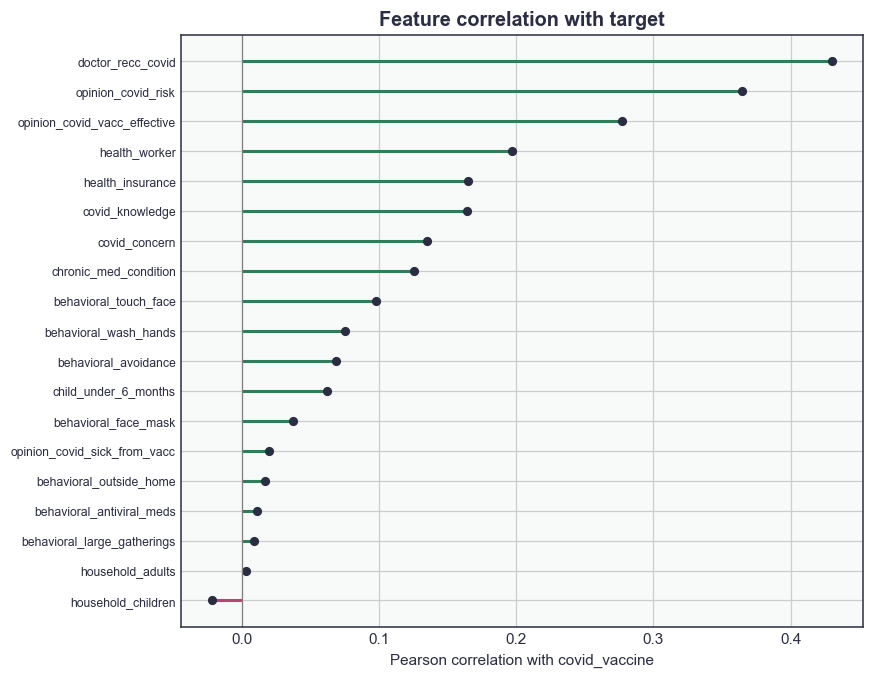

In [ ]:
corr=train.select_dtypes('number').drop(columns=[ID]).corr()[TARGET].drop(TARGET).sort_values()
colors=[ROSE if v<0 else EMERALD for v in corr.values]
plt.figure(figsize=(8,7))
plt.hlines(range(len(corr)),0,corr.values,color=colors,lw=2)
plt.plot(corr.values,range(len(corr)),'o',color=CHARCOAL,ms=5)
plt.axvline(0,c='grey',lw=.8); plt.yticks(range(len(corr)),corr.index,fontsize=8)
plt.xlabel('Pearson correlation with covid_vaccine'); plt.title('Feature correlation with target'); plt.show()

### <span style="color:#3d6098">**3.5 Vaccination-Rate Trends — Line Plots**</span>

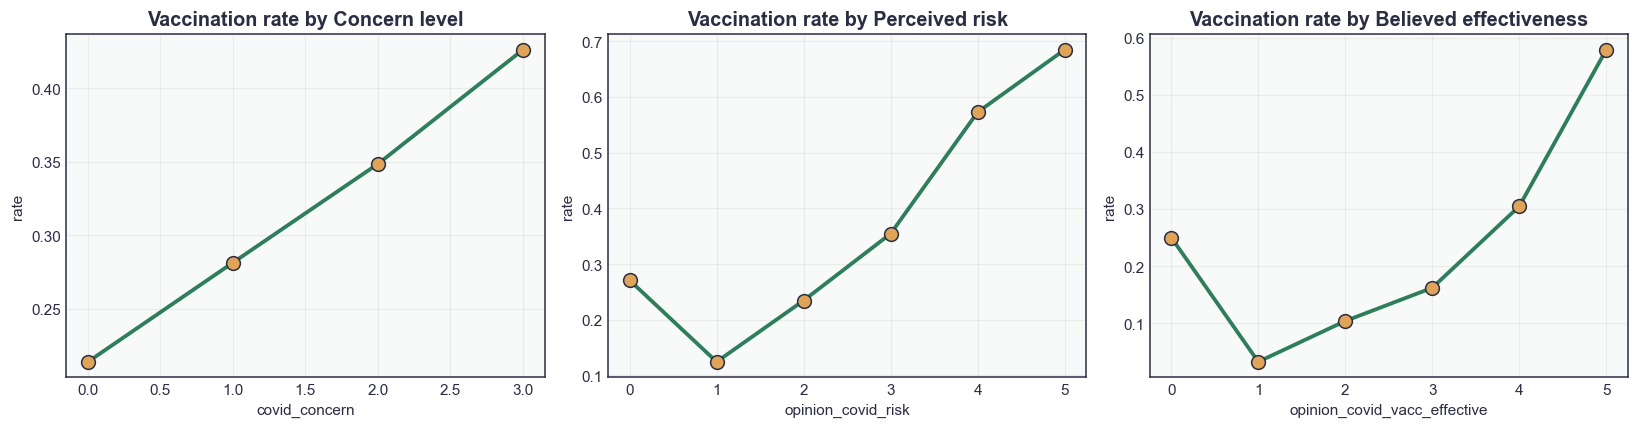

In [ ]:
fig,ax=plt.subplots(1,3,figsize=(15,4))
for a,col,t in zip(ax,['covid_concern','opinion_covid_risk','opinion_covid_vacc_effective'],
                   ['Concern level','Perceived risk','Believed effectiveness']):
    g=train.groupby(col)[TARGET].mean()
    a.plot(g.index,g.values,'o-',color=EMERALD,lw=2.5,ms=9,mfc=AMBER,mec=CHARCOAL)
    a.set_title('Vaccination rate by '+t); a.set_xlabel(col); a.set_ylabel('rate'); a.grid(alpha=.3)
plt.tight_layout(); plt.show()

### <span style="color:#3d6098">**3.6 Demographics — Stacked Bars**</span>

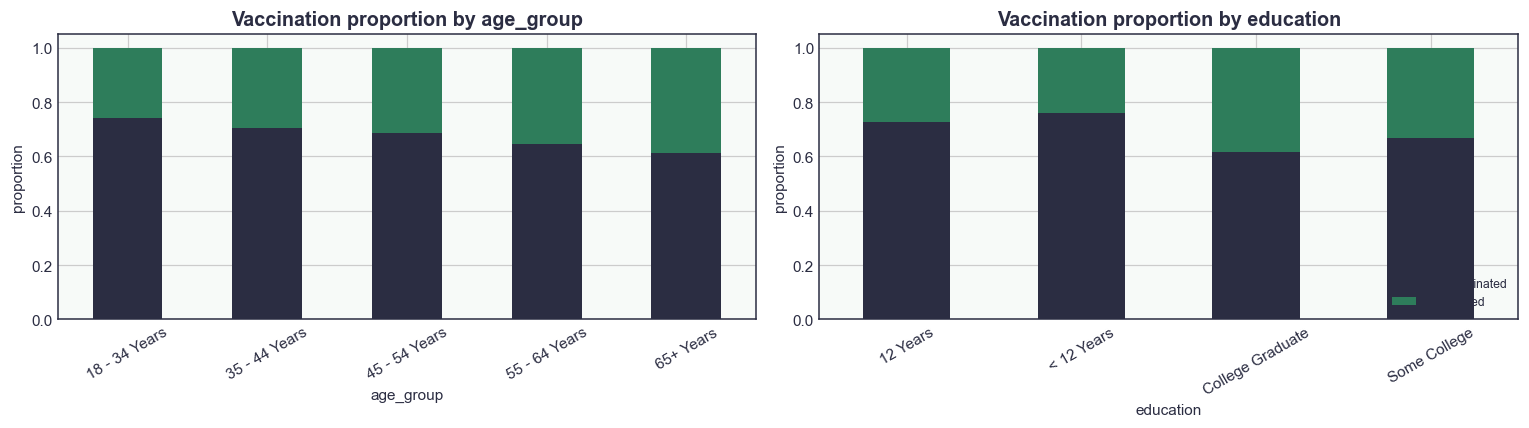

In [ ]:
fig,ax=plt.subplots(1,2,figsize=(14,4))
for a,col in zip(ax,['age_group','education']):
    ct=pd.crosstab(train[col],train[TARGET],normalize='index')
    ct.plot(kind='bar',stacked=True,color=[CHARCOAL,EMERALD],ax=a,legend=False)
    a.set_title('Vaccination proportion by '+col); a.set_ylabel('proportion'); a.tick_params(axis='x',rotation=30)
ax[1].legend(['Not vaccinated','Vaccinated'],loc='lower right',fontsize=8); plt.tight_layout(); plt.show()

### <span style="color:#3d6098">**3.7 PCA — Hexbin Density & Scree Plot**</span>

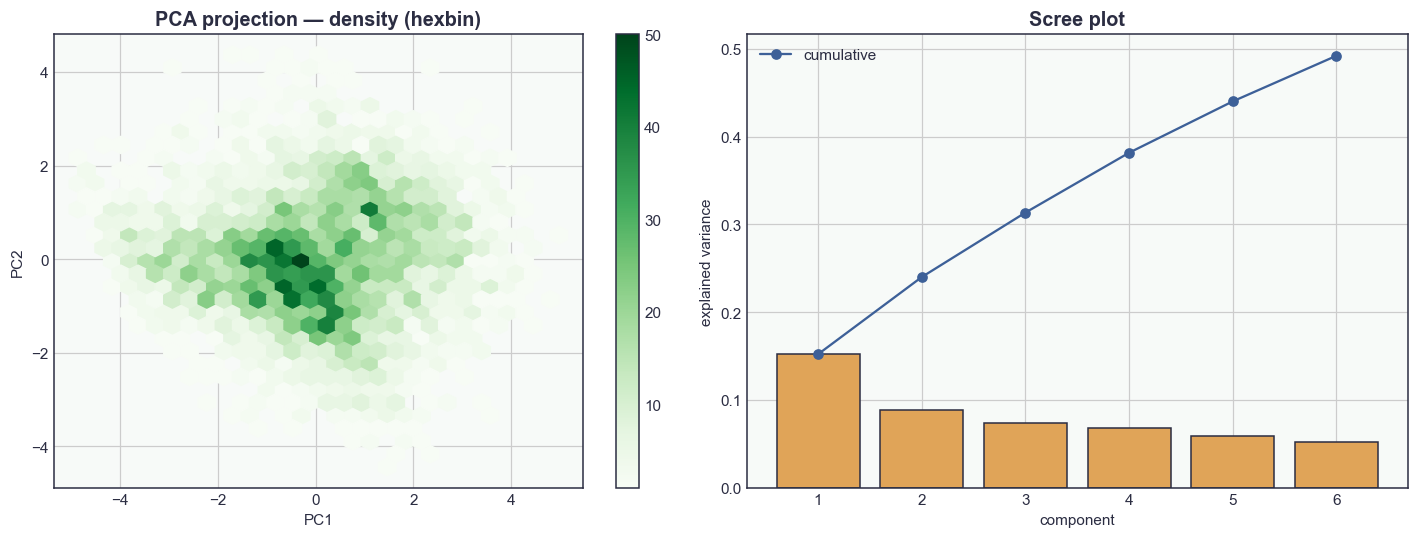

In [ ]:
pn=train.select_dtypes('number').drop(columns=[ID,TARGET]); pn=pn.fillna(pn.median())
pca=PCA(n_components=6,random_state=SEED); comp=pca.fit_transform(StandardScaler().fit_transform(pn))
fig,ax=plt.subplots(1,2,figsize=(13,5))
hb=ax[0].hexbin(comp[:,0],comp[:,1],gridsize=28,cmap='Greens',mincnt=1)
ax[0].set_title('PCA projection — density (hexbin)'); ax[0].set_xlabel('PC1'); ax[0].set_ylabel('PC2'); fig.colorbar(hb,ax=ax[0])
ax[1].bar(range(1,7),pca.explained_variance_ratio_,color=AMBER,edgecolor=CHARCOAL)
ax[1].plot(range(1,7),np.cumsum(pca.explained_variance_ratio_),'o-',color=STEEL,label='cumulative')
ax[1].set_title('Scree plot'); ax[1].set_xlabel('component'); ax[1].set_ylabel('explained variance'); ax[1].legend()
plt.tight_layout(); plt.show()

## <span style="color:#2e7d5b">&#9632;</span> <span style="color:#2b2d42">**4. Preprocessing & Feature Engineering (one-hot + frequency encoding)**</span>

In [ ]:
CAT=['age_group','education','race','sex','income_poverty','marital_status','rent_or_own','employment_status','census_msa']
FREQ='employment_sector'
def prepare(df_tr,df_te):
    tr=df_tr.drop(columns=[ID]).copy(); te=df_te.drop(columns=[ID]).copy()
    beh=['behavioral_antiviral_meds','behavioral_avoidance','behavioral_face_mask','behavioral_wash_hands',
         'behavioral_large_gatherings','behavioral_outside_home','behavioral_touch_face']
    for d in (tr,te):
        d['total_precautions']=d[beh].sum(axis=1)
        d['opinion_mean']=d[['opinion_covid_vacc_effective','opinion_covid_risk','opinion_covid_sick_from_vacc']].mean(axis=1)
    freq=tr[FREQ].value_counts(normalize=True)
    tr['emp_freq']=tr[FREQ].map(freq).fillna(0); te['emp_freq']=te[FREQ].map(freq).fillna(0)
    tr=tr.drop(columns=[FREQ]); te=te.drop(columns=[FREQ])
    tr=pd.get_dummies(tr,columns=CAT,dummy_na=True); te=pd.get_dummies(te,columns=CAT,dummy_na=True)
    tr,te=tr.align(te,join='left',axis=1,fill_value=0)
    num=tr.select_dtypes('number').columns; med=tr[num].median()
    tr[num]=tr[num].fillna(med); te[num]=te[num].fillna(med)
    tr=tr.drop(columns=[TARGET],errors='ignore'); te=te.drop(columns=[TARGET],errors='ignore')
    clean=lambda col: re.sub(r'[^0-9A-Za-z_]+','_',str(col)).strip('_')
    tr.columns=[clean(col) for col in tr.columns]; te.columns=[clean(col) for col in te.columns]
    return tr,te
X,X_test=prepare(train,test); print('design matrix',X.shape)

design matrix (4756, 59)


## <span style="color:#2e7d5b">&#9632;</span> <span style="color:#2b2d42">**5. Five Models**</span>

In [ ]:
models={
  'DecisionTree': DecisionTreeClassifier(max_depth=6,min_samples_leaf=30,random_state=SEED),
  'ExtraTrees':   ExtraTreesClassifier(n_estimators=400,min_samples_leaf=5,max_features='sqrt',n_jobs=-1,random_state=SEED),
  'HistGBM':      HistGradientBoostingClassifier(learning_rate=0.05,max_iter=400,max_leaf_nodes=31,min_samples_leaf=30,l2_regularization=1.0,random_state=SEED),
  'LightGBM':     LGBMClassifier(n_estimators=400,learning_rate=0.05,num_leaves=31,min_child_samples=30,subsample=0.85,subsample_freq=1,colsample_bytree=0.85,reg_lambda=1.0,random_state=SEED,verbose=-1),
}

## <span style="color:#2e7d5b">&#9632;</span> <span style="color:#2b2d42">**6. Cross-Validated Evaluation (base models)**</span>

In [ ]:
cv=StratifiedKFold(5,shuffle=True,random_state=SEED); oof={}; test_pred={}
for name,model in models.items():
    oof[name]=cross_val_predict(model,X,y,cv=cv,method='predict_proba',n_jobs=5)[:,1]
    model.fit(X,y); test_pred[name]=model.predict_proba(X_test)[:,1]
    print(f'{name:14s} OOF ROC-AUC {roc_auc_score(y,oof[name]):.4f}')

DecisionTree   OOF ROC-AUC 0.8029
ExtraTrees     OOF ROC-AUC 0.8282
HistGBM        OOF ROC-AUC 0.8177
LightGBM       OOF ROC-AUC 0.8217


## <span style="color:#2e7d5b">&#9632;</span> <span style="color:#2b2d42">**7. Soft-Voting Ensemble (Model 5)**</span>

In [ ]:
oof['Voting']=np.mean([oof[n] for n in models],axis=0)
test_pred['Voting']=np.mean([test_pred[n] for n in models],axis=0)
print('Voting OOF ROC-AUC %.4f'%roc_auc_score(y,oof['Voting']))

Voting OOF ROC-AUC 0.8292


## <span style="color:#2e7d5b">&#9632;</span> <span style="color:#2b2d42">**8. Evaluation Matrix — All Models (Accuracy, Precision, Recall, F1, ROC-AUC)**</span>

       model  ROC-AUC  Accuracy  Precision  Recall     F1
      Voting   0.8292    0.7860     0.7241  0.5573 0.6298
  ExtraTrees   0.8282    0.7887     0.7612  0.5148 0.6142
    LightGBM   0.8217    0.7803     0.6962  0.5811 0.6335
     HistGBM   0.8177    0.7765     0.6922  0.5689 0.6245
DecisionTree   0.8029    0.7769     0.7063  0.5431 0.6140


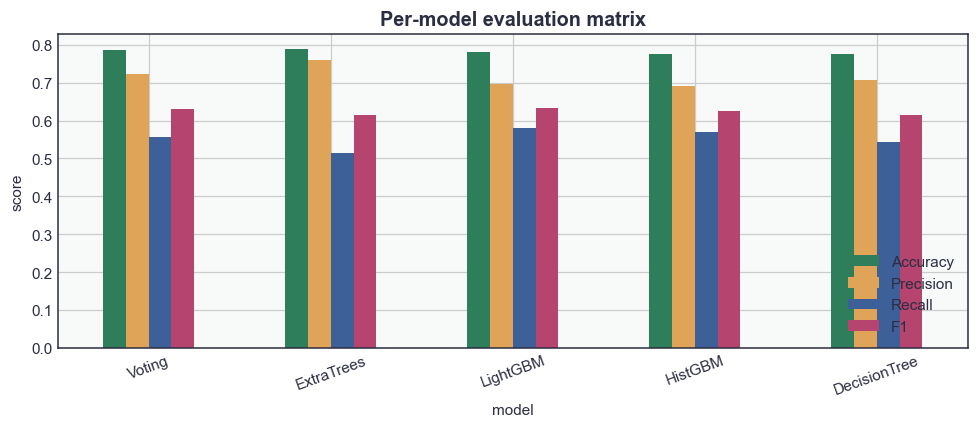

,model,ROC-AUC,Accuracy,Precision,Recall,F1
0,Voting,0.8292,0.7860,0.7241,0.5573,0.6298
1,ExtraTrees,0.8282,0.7887,0.7612,0.5148,0.6142
2,LightGBM,0.8217,0.7803,0.6962,0.5811,0.6335
3,HistGBM,0.8177,0.7765,0.6922,0.5689,0.6245
4,DecisionTree,0.8029,0.7769,0.7063,0.5431,0.6140


In [ ]:
rows=[]
for n in oof:
    p=(oof[n]>=0.5).astype(int)
    rows.append({'model':n,'ROC-AUC':round(roc_auc_score(y,oof[n]),4),'Accuracy':round(accuracy_score(y,p),4),
                 'Precision':round(precision_score(y,p),4),'Recall':round(recall_score(y,p),4),'F1':round(f1_score(y,p),4)})
eval_matrix=pd.DataFrame(rows).sort_values('ROC-AUC',ascending=False).reset_index(drop=True)
print(eval_matrix.to_string(index=False))
eval_matrix.set_index('model')[['Accuracy','Precision','Recall','F1']].plot(kind='bar',figsize=(9,4))
plt.title('Per-model evaluation matrix'); plt.ylabel('score'); plt.xticks(rotation=20); plt.legend(loc='lower right'); plt.tight_layout(); plt.show()
eval_matrix

## <span style="color:#2e7d5b">&#9632;</span> <span style="color:#2b2d42">**9. Performance of Best Model**</span>

best model: Voting
              precision    recall  f1-score   support

          No      0.807     0.897     0.849      3202
         Yes      0.724     0.557     0.630      1554

    accuracy                          0.786      4756
   macro avg      0.765     0.727     0.740      4756
weighted avg      0.780     0.786     0.778      4756



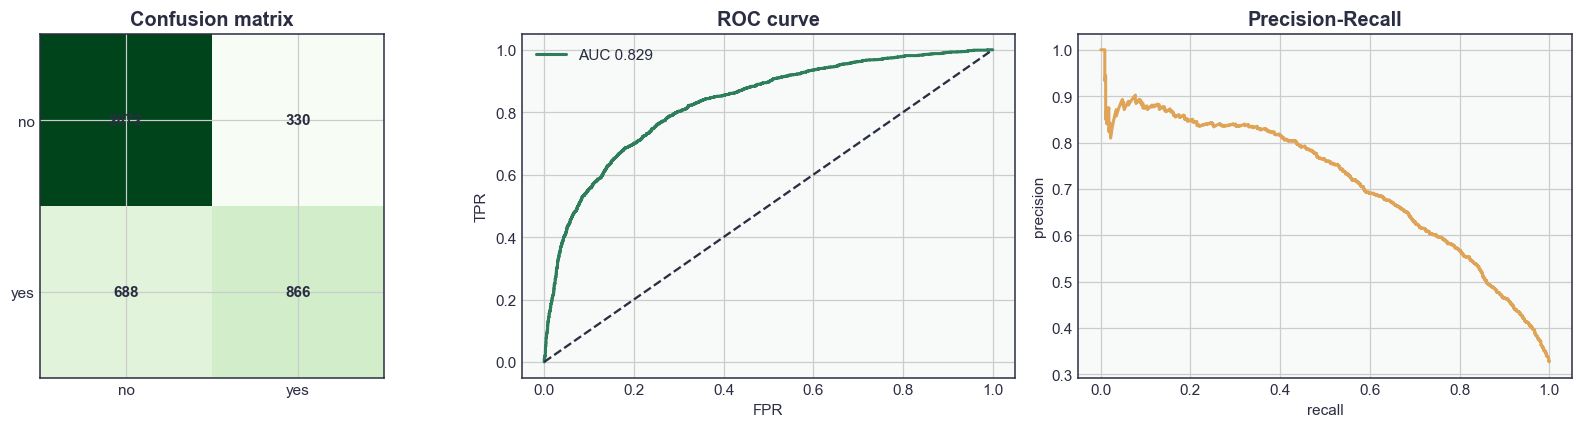

In [ ]:
best=eval_matrix.iloc[0]['model']; pr=(oof[best]>=0.5).astype(int)
print('best model:',best); print(classification_report(y,pr,target_names=['No','Yes'],digits=3))
cm=confusion_matrix(y,pr); fig,ax=plt.subplots(1,3,figsize=(15,4))
ax[0].imshow(cm,cmap=CMAP); ax[0].set_title('Confusion matrix'); ax[0].set_xticks([0,1]); ax[0].set_yticks([0,1])
ax[0].set_xticklabels(['no','yes']); ax[0].set_yticklabels(['no','yes'])
for i in range(2):
    for j in range(2): ax[0].text(j,i,cm[i,j],ha='center',va='center',color=CHARCOAL,fontweight='bold')
fpr,tpr,_=roc_curve(y,oof[best]); ax[1].plot(fpr,tpr,color=EMERALD,lw=2,label='AUC %.3f'%roc_auc_score(y,oof[best])); ax[1].plot([0,1],[0,1],'--',c=CHARCOAL)
ax[1].set_title('ROC curve'); ax[1].legend(); ax[1].set_xlabel('FPR'); ax[1].set_ylabel('TPR')
p2,r2,_=precision_recall_curve(y,oof[best]); ax[2].plot(r2,p2,color=AMBER,lw=2); ax[2].set_title('Precision-Recall'); ax[2].set_xlabel('recall'); ax[2].set_ylabel('precision')
plt.tight_layout(); plt.show()

## <span style="color:#2e7d5b">&#9632;</span> <span style="color:#2b2d42">**10. Hyperparameter Tuning (GridSearchCV)**</span>

In [ ]:
lgbm=LGBMClassifier(random_state=SEED,verbose=-1)
grid={'n_estimators':[300,500],'learning_rate':[0.03,0.05],'num_leaves':[31,63]}
gs=GridSearchCV(lgbm,grid,scoring='roc_auc',cv=3,n_jobs=5); gs.fit(X,y)
print('best params:',gs.best_params_); print('tuned CV ROC-AUC %.4f'%gs.best_score_)

best params: {'learning_rate': 0.03, 'n_estimators': 300, 'num_leaves': 31}
tuned CV ROC-AUC 0.8203


## <span style="color:#2e7d5b">&#9632;</span> <span style="color:#2b2d42">**11. Explainable AI — Permutation Importance & Shapley Values**</span>

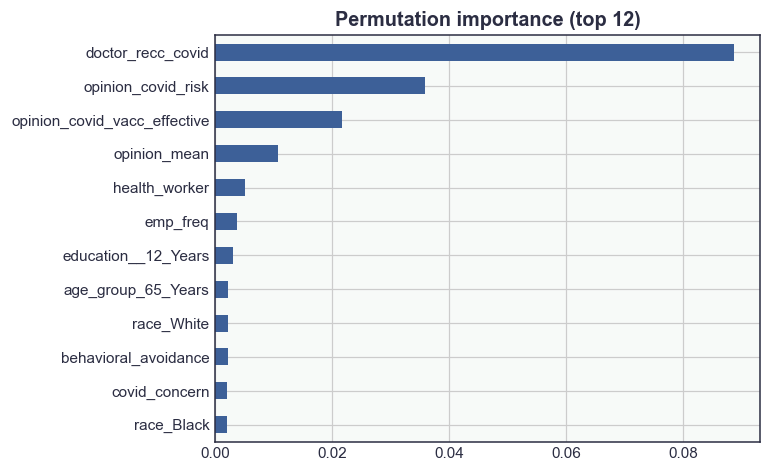

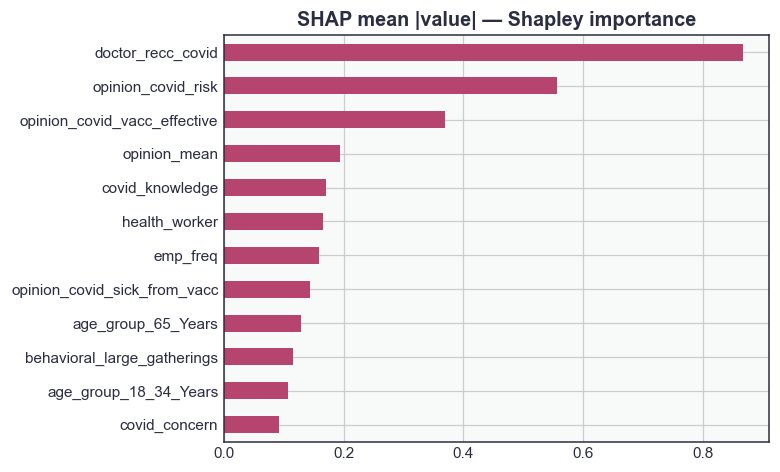

In [ ]:
Xtr,Xva,ytr,yva=train_test_split(X,y,test_size=0.3,stratify=y,random_state=SEED)
pm=models['LightGBM']; pm.fit(Xtr,ytr)
pi=permutation_importance(pm,Xva,yva,scoring='roc_auc',n_repeats=5,random_state=SEED,n_jobs=5)
pd.Series(pi.importances_mean,index=X.columns).sort_values().tail(12).plot(kind='barh',color=STEEL)
plt.title('Permutation importance (top 12)'); plt.show()
lg=LGBMClassifier(n_estimators=400,learning_rate=0.05,num_leaves=31,random_state=SEED,verbose=-1); lg.fit(X,y)
contrib=lg.booster_.predict(X.iloc[:1500].values,pred_contrib=True)
pd.Series(np.abs(contrib[:,:-1]).mean(0),index=X.columns).sort_values().tail(12).plot(kind='barh',color=ROSE)
plt.title('SHAP mean |value| — Shapley importance'); plt.show()

## <span style="color:#2e7d5b">&#9632;</span> <span style="color:#2b2d42">**12. Decision-Threshold Optimization**</span>

best F1 0.6665 at threshold 0.26 (F1 at 0.5 = 0.6298)


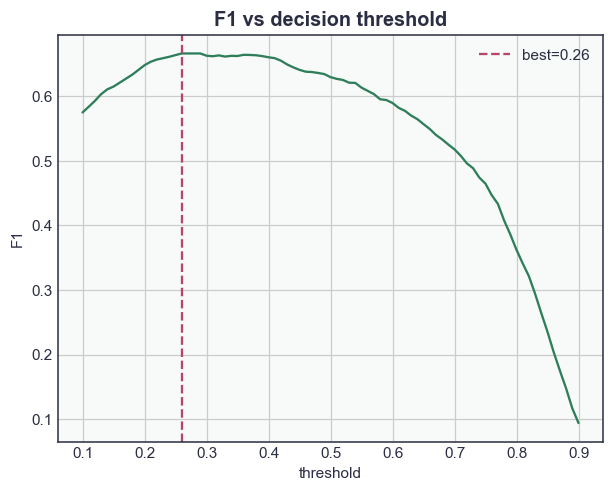

In [ ]:
ths=np.linspace(0.1,0.9,81); f1s=[f1_score(y,(oof[best]>=t).astype(int)) for t in ths]; bt=ths[int(np.argmax(f1s))]
print('best F1 %.4f at threshold %.2f (F1 at 0.5 = %.4f)'%(max(f1s),bt,f1_score(y,(oof[best]>=0.5).astype(int))))
plt.plot(ths,f1s,color=EMERALD); plt.axvline(bt,c=ROSE,ls='--',label='best=%.2f'%bt)
plt.title('F1 vs decision threshold'); plt.xlabel('threshold'); plt.ylabel('F1'); plt.legend(); plt.show()

## <span style="color:#2e7d5b">&#9632;</span> <span style="color:#2b2d42">**13. Learning Curve & Calibration**</span>

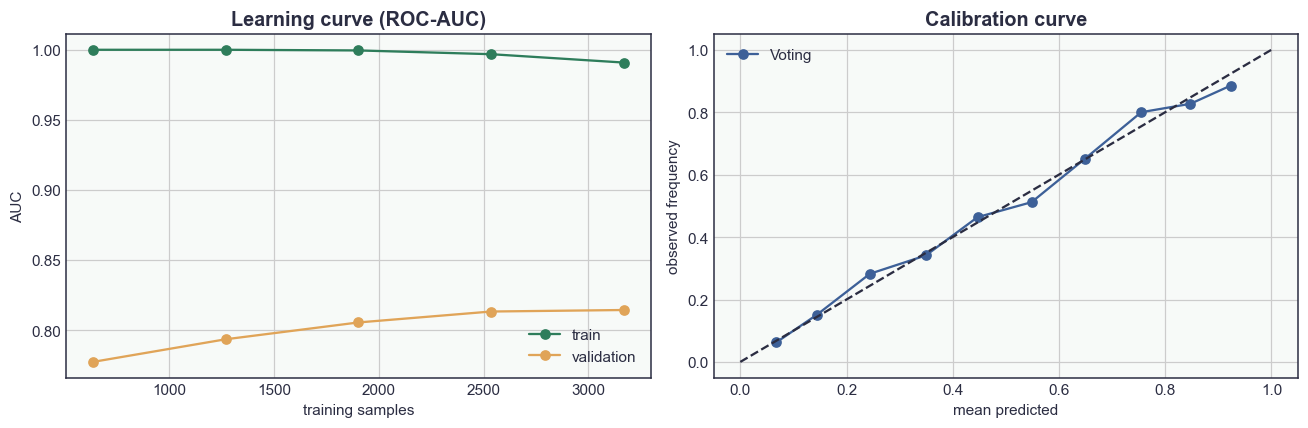

In [ ]:
est=LGBMClassifier(n_estimators=300,learning_rate=0.05,num_leaves=31,random_state=SEED,verbose=-1)
sizes,tr_s,va_s=learning_curve(est,X,y,cv=3,scoring='roc_auc',train_sizes=np.linspace(0.2,1.0,5),n_jobs=5)
fig,ax=plt.subplots(1,2,figsize=(12,4))
ax[0].plot(sizes,tr_s.mean(1),'o-',color=EMERALD,label='train'); ax[0].plot(sizes,va_s.mean(1),'o-',color=AMBER,label='validation')
ax[0].set_title('Learning curve (ROC-AUC)'); ax[0].set_xlabel('training samples'); ax[0].set_ylabel('AUC'); ax[0].legend()
fp,mp=calibration_curve(y,oof[best],n_bins=10)
ax[1].plot(mp,fp,'o-',color=STEEL,label=best); ax[1].plot([0,1],[0,1],'--',c=CHARCOAL)
ax[1].set_title('Calibration curve'); ax[1].set_xlabel('mean predicted'); ax[1].set_ylabel('observed frequency'); ax[1].legend()
plt.tight_layout(); plt.show()

## <span style="color:#2e7d5b">&#9632;</span> <span style="color:#2b2d42">**14. Ranked Submissions (binary 0/1 to match example)**</span>

In [ ]:
# submissions written as binary 0/1 labels (threshold 0.5) to match the example file
ranked=sorted(oof,key=lambda n:-roc_auc_score(y,oof[n])); rows=[]
for rank,name in enumerate(ranked,1):
    fn=f'submission_{rank}_{name.lower()}.csv'
    pd.DataFrame({ID:test[ID],TARGET:(test_pred[name]>=0.5).astype(int)}).to_csv(fn,index=False)
    rows.append({'rank':rank,'file':fn,'model':name,'CV ROC-AUC':round(roc_auc_score(y,oof[name]),4)})
top=ranked[0]; pd.DataFrame({ID:test[ID],TARGET:(test_pred[top]>=0.5).astype(int)}).to_csv('submission.csv',index=False)
print('saved ranked submissions + submission.csv (binary)'); pd.DataFrame(rows)

saved ranked submissions + submission.csv (binary)


,rank,file,model,CV ROC-AUC
0,1,submission_1_voting.csv,Voting,0.8292
1,2,submission_2_extratrees.csv,ExtraTrees,0.8282
2,3,submission_3_lightgbm.csv,LightGBM,0.8217
3,4,submission_4_histgbm.csv,HistGBM,0.8177
4,5,submission_5_decisiontree.csv,DecisionTree,0.8029
